# Source E — Key Findings: IRS Statistics of Income Panel Data

This notebook shows the already-verified results from
`analysis-output/source-e/source-e-findings.md`. It loads computed artifacts
(`source_e_stats.json`, `source_e_tier_stats.json`, saved figures, the
capital-composition and crossvalidation CSVs) rather than re-deriving them.

**Round 2 (2026-08-04).** Sections 4–7 are new, and two round-1 conclusions did
not survive them: the ratio's tail noise is a *concentrated-gain* mechanism
rather than a *low-return* one, and the round-1 advice to weight by
`num_returns` runs backwards. Both corrections are shown in section 7.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "source-e" else Path.cwd()
ANALYSIS_DIR = REPO_ROOT / "analysis-output" / "source-e"
FIGURES_DIR = ANALYSIS_DIR / "figures"

with open(ANALYSIS_DIR / "source_e_stats.json") as f:
    stats = json.load(f)
with open(ANALYSIS_DIR / "source_e_tier_stats.json") as f:
    tier_stats = json.load(f)

print("tax years in the panel:", tier_stats["tax_years"])
stats["ratio_stats"]

tax years in the panel: [2018, 2019, 2020, 2021, 2022]


{'mean': 0.10745513816041805,
 'median': 0.08224652238595272,
 'max': 2.798465773124988,
 'min': 0.0}

## 1. Dataset

`data/source_e_irs_soi.parquet` — 3,143 counties × 24 columns, IRS SOI Tax Year
2022 county aggregates plus cross-year summaries. `data/source_e_irs_soi_panel.parquet`
carries the same measures one row per county per tax year, TY2018–TY2022.

Coverage is 3,143 of 3,144 crosswalk counties. The gap is Kalawao County, HI
(population ~90) — the same county Source B independently misses.

In [2]:
source_e_df = pd.read_parquet(REPO_ROOT / "data" / "source_e_irs_soi.parquet")
panel_df = pd.read_parquet(REPO_ROOT / "data" / "source_e_irs_soi_panel.parquet")

print(f"{len(source_e_df):,} counties x {source_e_df.shape[1]} columns")
print(f"{len(panel_df):,} panel rows across {panel_df['tax_year'].nunique()} tax years")
source_e_df[[
    "county_name", "num_returns", "capital_to_wage_ratio",
    "capital_to_wage_ratio_normalized_mean", "capgain_participation_rate",
]].head()

3,143 counties x 24 columns
15,686 panel rows across 5 tax years


,county_name,num_returns,capital_to_wage_ratio,capital_to_wage_ratio_normalized_mean,capgain_participation_rate
0,"Autauga County, Alabama",25750.0,0.040277,0.249011,0.125825
1,"Baldwin County, Alabama",113660.0,0.170460,0.896963,0.200158
2,"Barbour County, Alabama",9590.0,0.079666,0.429037,0.099062
3,"Bibb County, Alabama",8220.0,0.024429,0.388352,0.065693
4,"Blount County, Alabama",24370.0,0.039927,0.208765,0.091096


## 2. Finding: the ratio validates against well-known resort geography

Before any correlation analysis, the top of the ranking is recognizable:
Teton WY (Jackson Hole), Pitkin CO (Aspen), Blaine ID (Sun Valley), Collier FL
(Naples), Monroe FL (the Keys). That is the county profile the proposal's
"asset-rich, investment-driven markets" framing describes.

One large county does not fit that story: Benton County, AR (138,170 returns,
no resort) is home to Walmart, Tyson, and J.B. Hunt — concentrated executive
equity, a third mechanism the framing does not name but the ratio picks up.

In [3]:
capital_composition = pd.read_csv(REPO_ROOT / "outputs" / "source_e_capital_composition.csv")
capital_composition.nlargest(10, "capital_to_wage_ratio")[
    ["county_name", "capital_to_wage_ratio"]
]

,county_name,capital_to_wage_ratio
3139,"Teton County, Wyoming",2.798466
294,"Pitkin County, Colorado",1.571092
558,"Blaine County, Idaho",1.243861
332,"Collier County, Florida",1.128669
365,"Monroe County, Florida",1.106065
302,"San Miguel County, Colorado",1.084007
2732,"Shackelford County, Texas",0.996979
351,"Indian River County, Florida",0.973849
371,"Palm Beach County, Florida",0.964405
363,"Martin County, Florida",0.892518


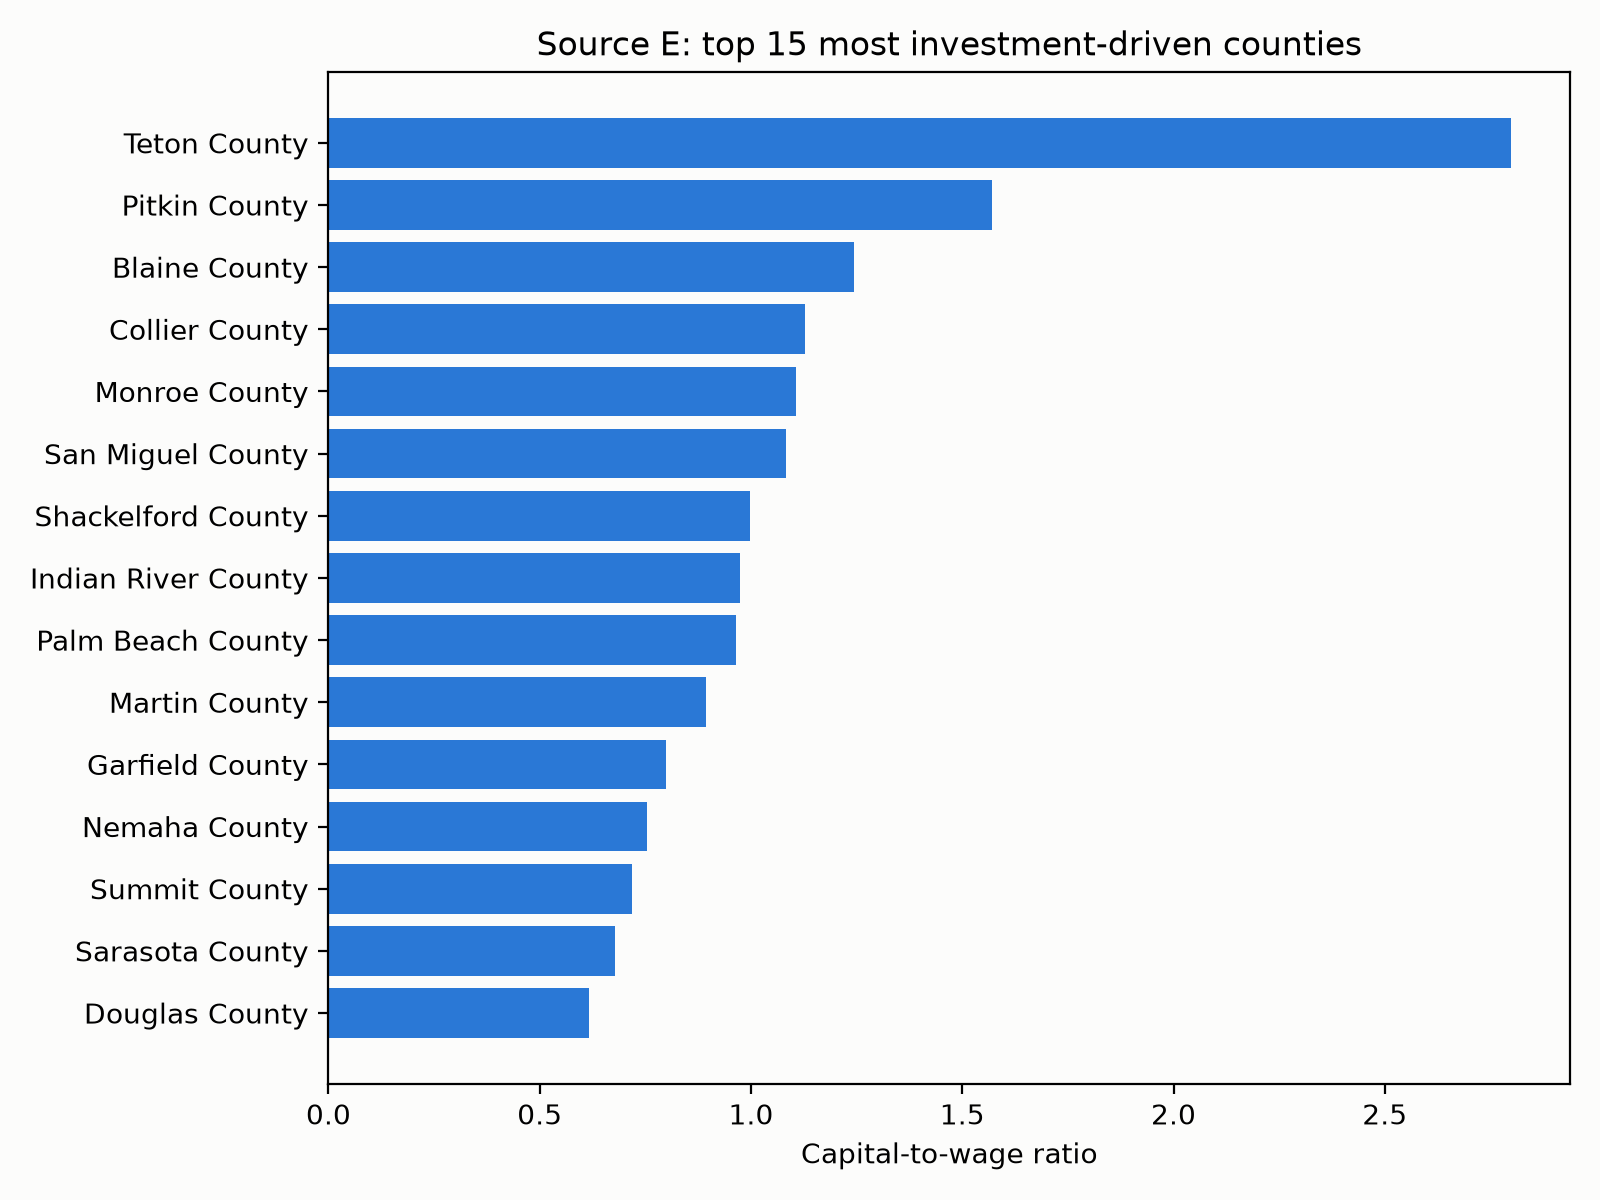

In [4]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-01-top-investment-driven.png")))

## 3. Finding: no suppression flag, unlike Source B

BLS QCEW ships a `disclosure_code` beside every suppressed cell. The IRS county
file ships nothing — a suppressed small cell and a genuine zero are both written
as a bare `0`. Its practical footprint is 3 counties.

**Round 2 partly mitigates this.** The file's `N00200` / `N00650` / `N01000`
columns — how many returns underlie each amount — now ship as
`n_returns_*`. They are the closest thing this source has to the missing flag:
a consumer can see a thin sample instead of inferring it from `num_returns`.

In [5]:
zero_ratio = source_e_df[source_e_df["capital_to_wage_ratio"] == 0]
print("counties with an exact-zero ratio:", len(zero_ratio))
print("counties with zero filers reporting a capital gain:",
      int((source_e_df["n_returns_net_cap_gain"] == 0).sum()))
print("counties flagged thin_claimer (<100 filers behind the numerator):",
      int(source_e_df["thin_claimer_flag"].sum()))
zero_ratio[["county_name", "num_returns", "n_returns_net_cap_gain", "capital_to_wage_ratio"]]

counties with an exact-zero ratio: 3
counties with zero filers reporting a capital gain: 3
counties flagged thin_claimer (<100 filers behind the numerator): 37


,county_name,num_returns,n_returns_net_cap_gain,capital_to_wage_ratio
2654,"Kenedy County, Texas",140.0,0.0,0.0
2658,"King County, Texas",100.0,0.0,0.0
2674,"Loving County, Texas",40.0,0.0,0.0


## 4. Finding: the ratio is three separable things, not one

`capital_to_wage_ratio` is a product of how many filers report investment
income, how much each reports, and how much wage income sits underneath.
Regressing its log on those three recovers **R² = 0.975** with near-unit
elasticities — so a high ratio can mean any of three different economies, and
the single column maps them onto the same number.

All three components now ship. The ratio stays for continuity.

In [6]:
components = ["capgain_participation_rate", "gain_per_claimer_thousands", "wage_per_return_thousands"]
fit_frame = source_e_df[components + ["capital_to_wage_ratio"]].replace(0, np.nan).dropna()

design = np.column_stack([np.ones(len(fit_frame))] + [np.log(fit_frame[c]) for c in components])
target = np.log(fit_frame["capital_to_wage_ratio"])
beta, *_ = np.linalg.lstsq(design, target, rcond=None)
residual = target - design @ beta
r_squared = 1 - (residual**2).sum() / ((target - target.mean())**2).sum()

print(f"log(ratio) ~ log(participation) + log(gain per claimer) + log(wage per return)")
print(f"  R^2 = {r_squared:.3f}   n = {len(fit_frame):,}")
for name, coefficient in zip(components, beta[1:]):
    print(f"  {name:32s} {coefficient:+.3f}")

log(ratio) ~ log(participation) + log(gain per claimer) + log(wage per return)
  R^2 = 0.975   n = 3,140
  capgain_participation_rate       +0.963
  gain_per_claimer_thousands       +0.895
  wage_per_return_thousands        -0.859


In [7]:
# Two counties the round-1 report grouped together under one flag, and what
# the components say about them. Both are low-return; only one is a land sale.
contrast = source_e_df[source_e_df["county_name"].str.startswith(
    ("Shackelford County", "Arthur County, Neb", "Teton County, Wyo")
)]
contrast[[
    "county_name", "num_returns", "capital_to_wage_ratio", "n_returns_net_cap_gain",
    "gain_per_claimer_thousands", "capgain_participation_rate",
    "low_return_flag", "concentrated_gain_flag",
]]

,county_name,num_returns,capital_to_wage_ratio,n_returns_net_cap_gain,gain_per_claimer_thousands,capgain_participation_rate,low_return_flag,concentrated_gain_flag
1657,"Arthur County, Nebraska",190.0,0.590705,90.0,31.400000,0.473684,True,False
2732,"Shackelford County, Texas",1490.0,0.996979,300.0,233.680000,0.201342,True,True
3139,"Teton County, Wyoming",15210.0,2.798466,6010.0,515.266556,0.395135,False,True


## 5. Finding: the market year sets the level, not the county

Round 1 listed the single reference year as a minor limitation. Across
TY2018–TY2022 it is the pillar's largest single weakness: the national
aggregate ratio runs 0.144 → 0.131 → 0.160 → **0.255** → 0.156. TY2021 is 64%
above TY2022 nationally — the equity market, not 3,143 county economies moving
together.

A model trained on the raw ratio and refreshed to a later tax year sees every
county shift at once. `capital_to_wage_ratio_normalized_mean` — each year's
ratio over that year's national aggregate, averaged across the five years — is
the column that survives a refresh, and the one downstream models should use.

In [8]:
panel_df.groupby("tax_year").agg(
    national_aggregate=("national_capital_to_wage_ratio", "first"),
    unweighted_county_mean=("capital_to_wage_ratio", "mean"),
    county_median=("capital_to_wage_ratio", "median"),
).round(4)

,national_aggregate,unweighted_county_mean,county_median
tax_year,,,
2018,0.1439,0.0923,0.0717
2019,0.1312,0.0843,0.0643
2020,0.1596,0.0945,0.0707
2021,0.2551,0.1562,0.1194
2022,0.1557,0.1075,0.0822


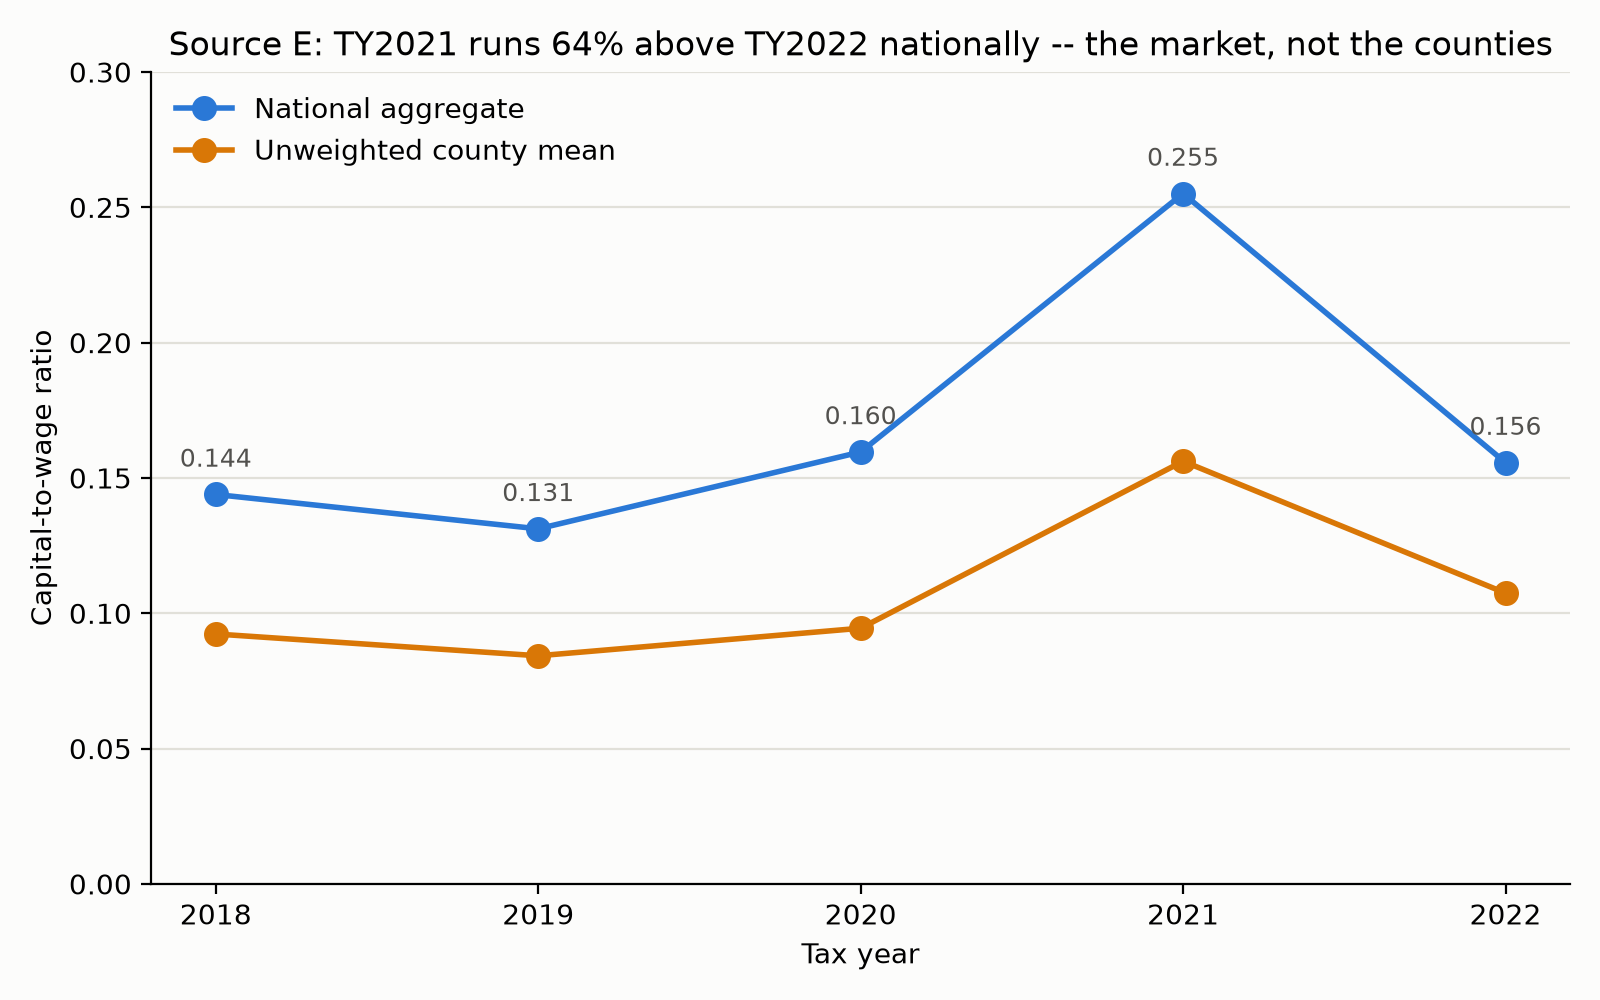

In [9]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-05-vintage-effect.png")))

## 6. Finding: four data-volume tiers, and where the money actually is

Source E does not behave the same way across county sizes, and a single national
statistic hides all of it. Counties split on `num_returns` at the
`low_return_flag` threshold, the national median, and 100k returns.

The asymmetry to take away: **T1 and T4 are each about a tenth of all counties.
T1 holds 0.14% of national investment income; T4 holds 82.6%.**

In [10]:
tiers = pd.DataFrame(tier_stats["tiers"]).T
tiers[[
    "n_counties", "share_of_investment_income", "median_ratio", "iqr_ratio",
    "median_relative_move", "source_b_real_estate_lq_pearson_r",
]].round(4)

,n_counties,share_of_investment_income,median_ratio,iqr_ratio,median_relative_move,source_b_real_estate_lq_pearson_r
T1 thin (<2.2k returns),325.0,0.0014,0.1161,0.1172,0.2979,-0.0582
T2 small (2.2k-11.7k),1246.0,0.0203,0.0734,0.0563,0.2797,0.3798
T3 mid (11.7k-100k),1246.0,0.1523,0.0797,0.0528,0.3331,0.4096
T4 large (>=100k),326.0,0.8260,0.1176,0.0815,0.3929,0.4756


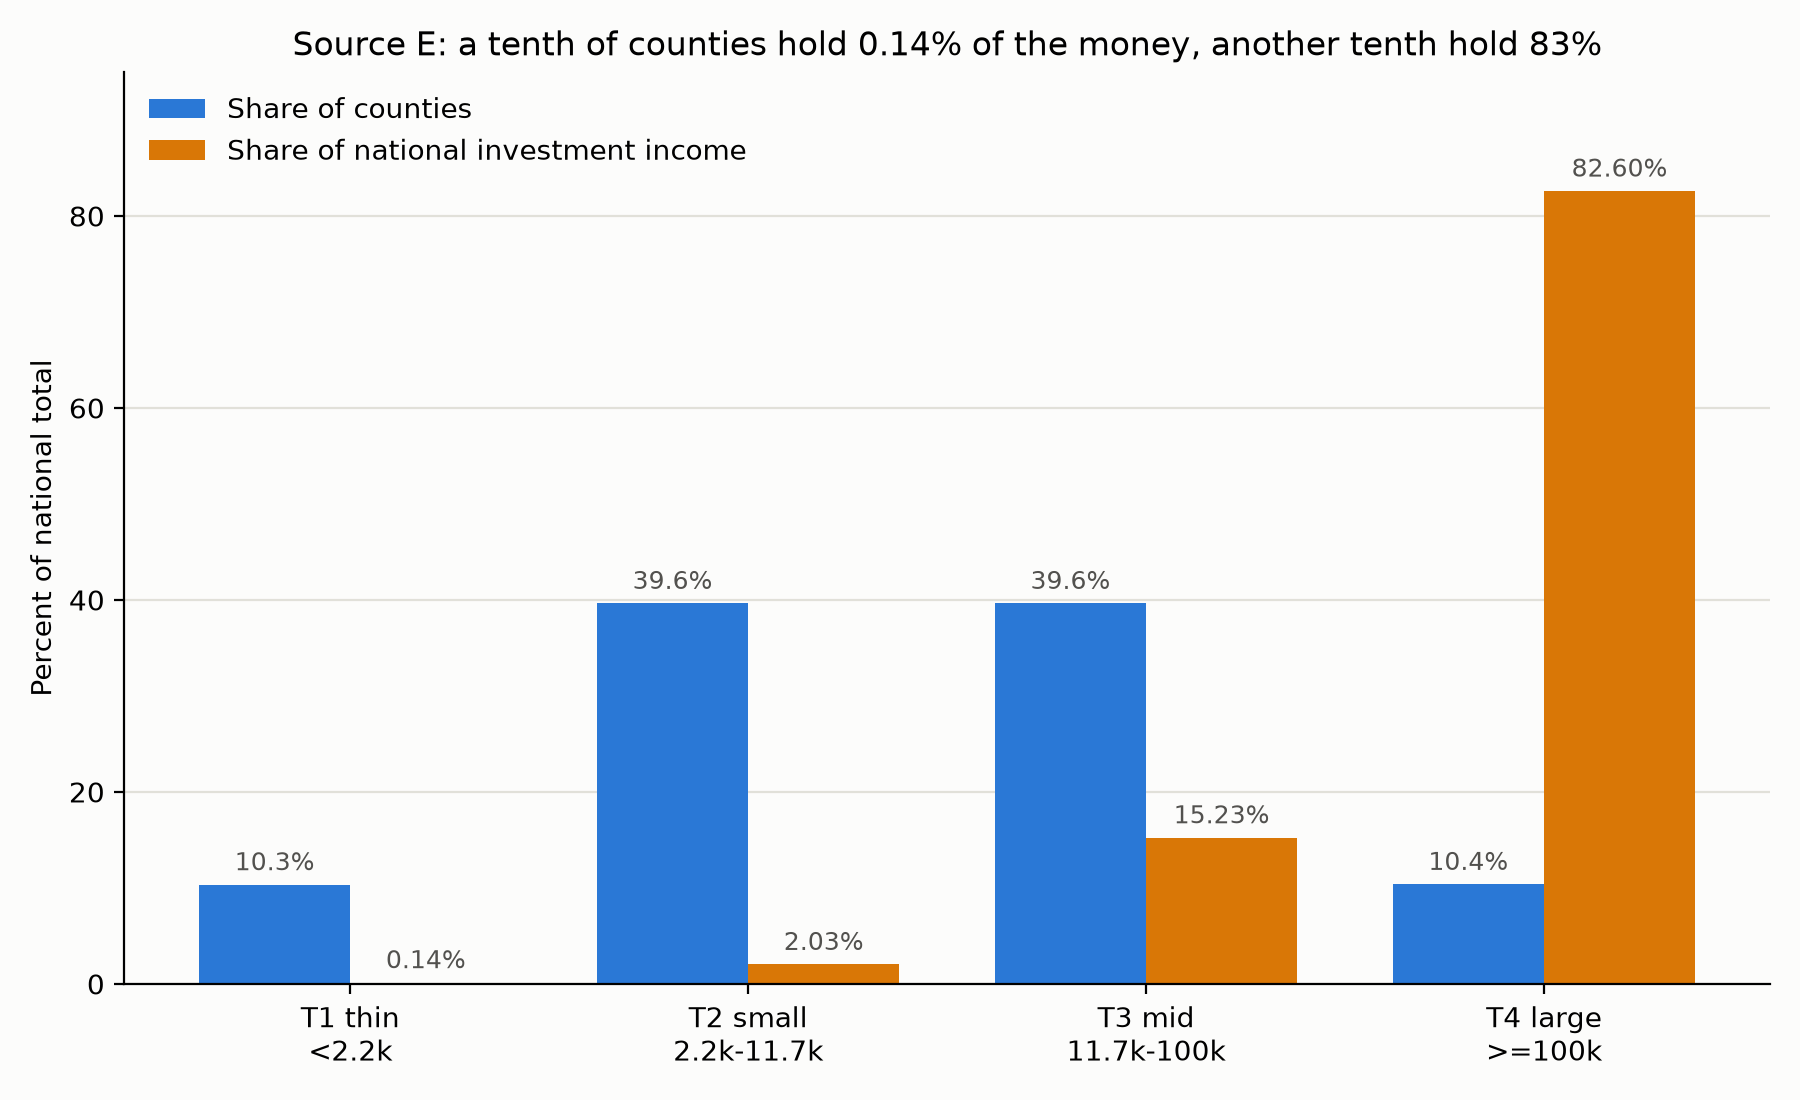

In [11]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-04-tier-economics.png")))

## 7. Two round-1 conclusions that ran backwards

**Correction 1 — small counties are the *more* stable group.** Median
year-over-year movement rises with size, 0.298 (T1) → 0.393 (T4). Round 1
advised weighting by `num_returns` to suppress noise; that upweights the
counties whose values move most between vintages. `low_return_flag` is
redocumented as a **materiality** flag, joined by `thin_claimer_flag` (trust the
level?) and `concentrated_gain_flag` (is this a land sale?).

**Correction 2 — the strongest surviving cross-pillar link is a large-county
effect.** B Real Estate LQ × E runs +0.394 nationally, +0.476 in T4, and
**−0.058 in T1**. A consumer serving rural geographies gets nothing from B ↔ E
and needs to know that before leaning on it.

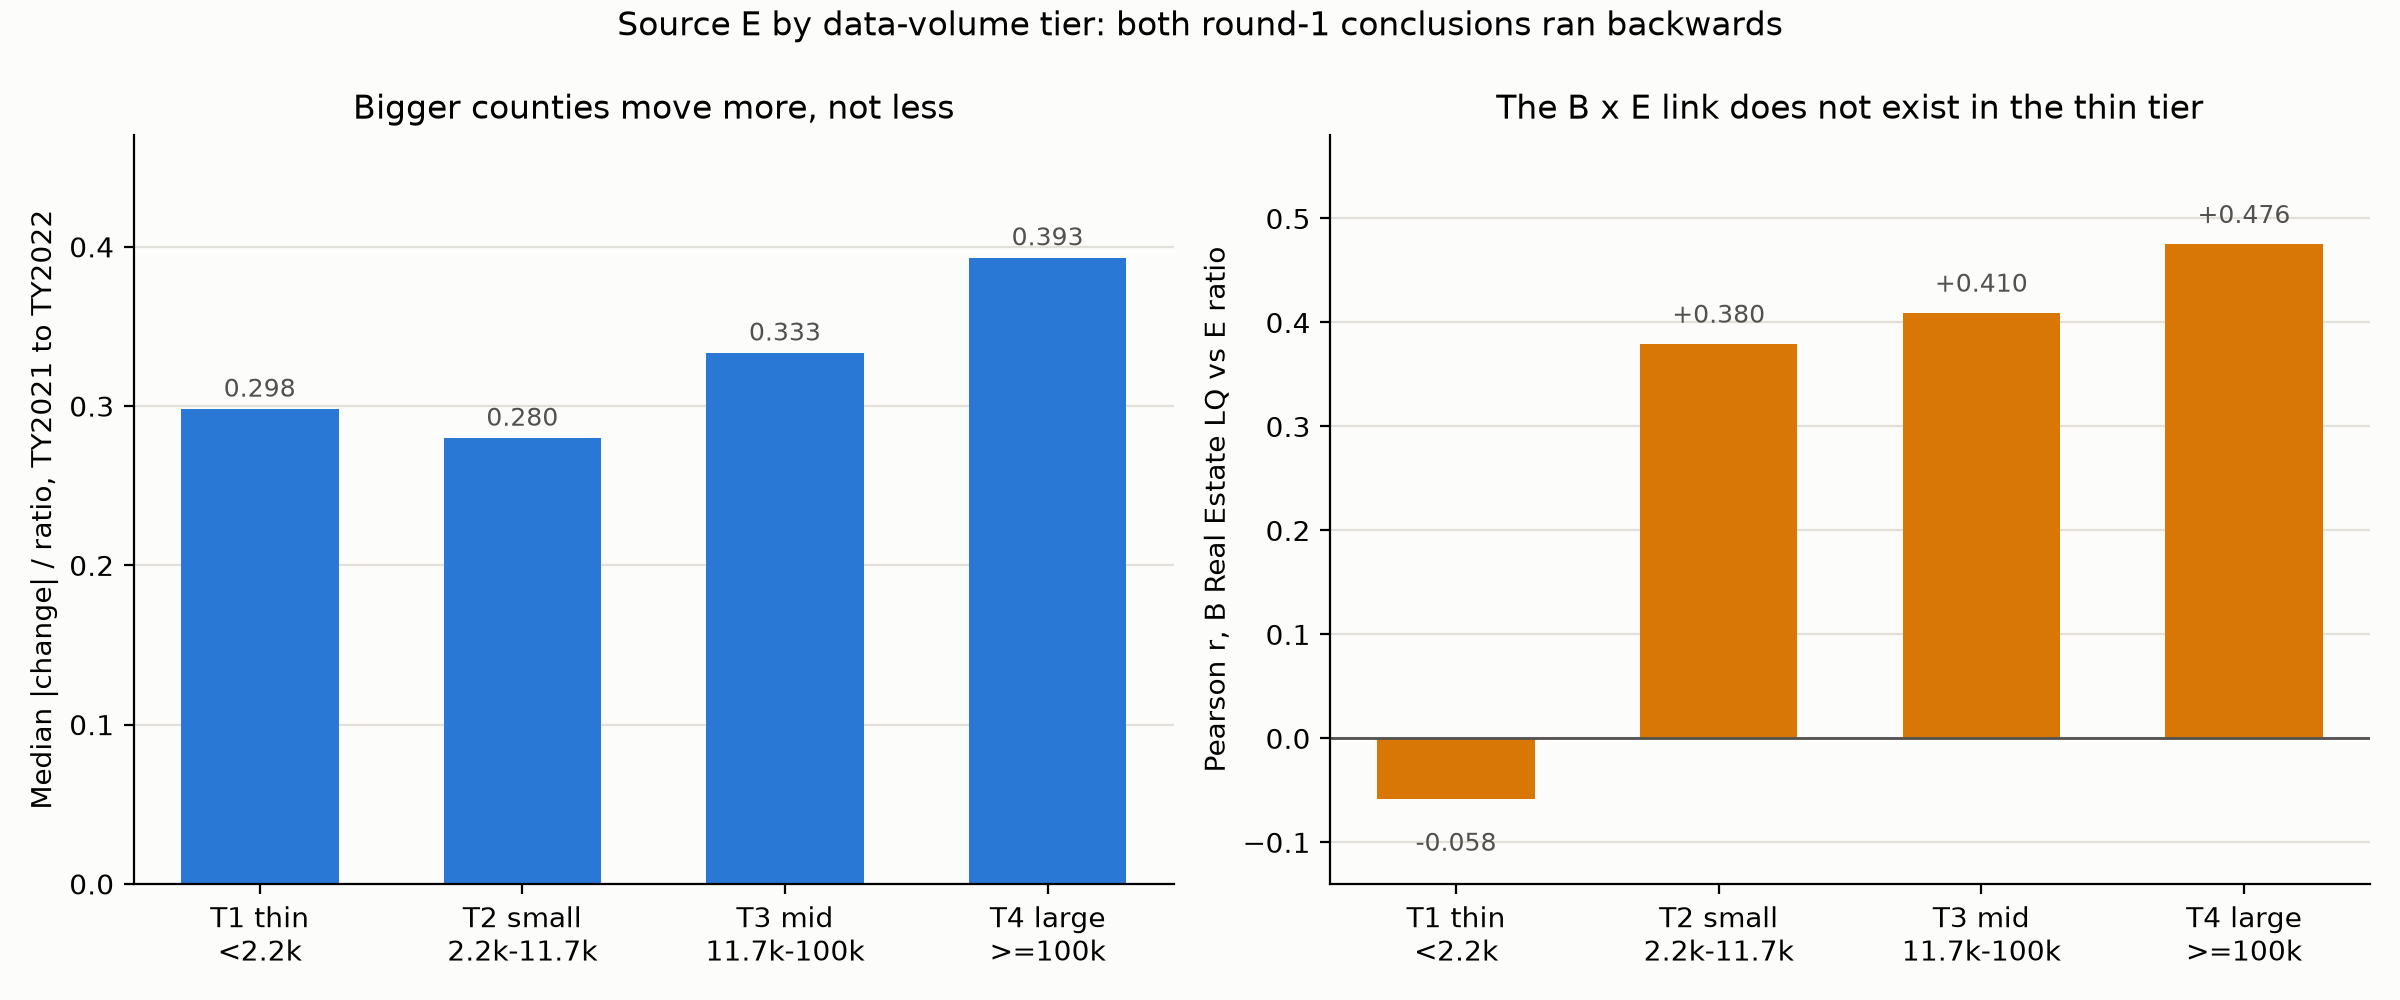

In [12]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-06-tier-behavior.png")))

In [13]:
# The two flags are close to independent -- one could never stand in for the other.
pd.crosstab(source_e_df["low_return_flag"], source_e_df["concentrated_gain_flag"])

concentrated_gain_flag,False,True
low_return_flag,,
False,2671,147
True,315,10


## 8. Finding: a weak GDP-velocity link, no unemployment link

Against Source C's velocity metrics, the capital-to-wage ratio shows a small but
clean association with size-normalized GDP velocity and none with unemployment
velocity. Mean GDP velocity rises monotonically across capital quartiles,
1.6% → 2.3%.

Directionally consistent with the proposal's framing — an investment-heavy
county's wealth tracks markets rather than local job survival — though the
effect sizes are small enough to read as consistent rather than confirming.

In [14]:
print("vs unemployment velocity: r =",
      round(stats["capital_to_wage_ratio_vs_unemployment_velocity_corr"], 4),
      " p =", stats["capital_to_wage_ratio_vs_unemployment_velocity_p"])
print("vs size-normalized GDP velocity: r =",
      round(stats["capital_to_wage_ratio_vs_gdp_velocity_pct_corr"], 4),
      " p =", stats["capital_to_wage_ratio_vs_gdp_velocity_pct_p"])
pd.Series(stats["gdp_velocity_pct_by_capital_quartile"], name="mean GDP velocity").round(4)

vs unemployment velocity: r = -0.0297  p = 0.112
vs size-normalized GDP velocity: r = 0.0705  p = 0.002


1    0.0161
2    0.0180
3    0.0203
4    0.0228
Name: mean GDP velocity, dtype: float64

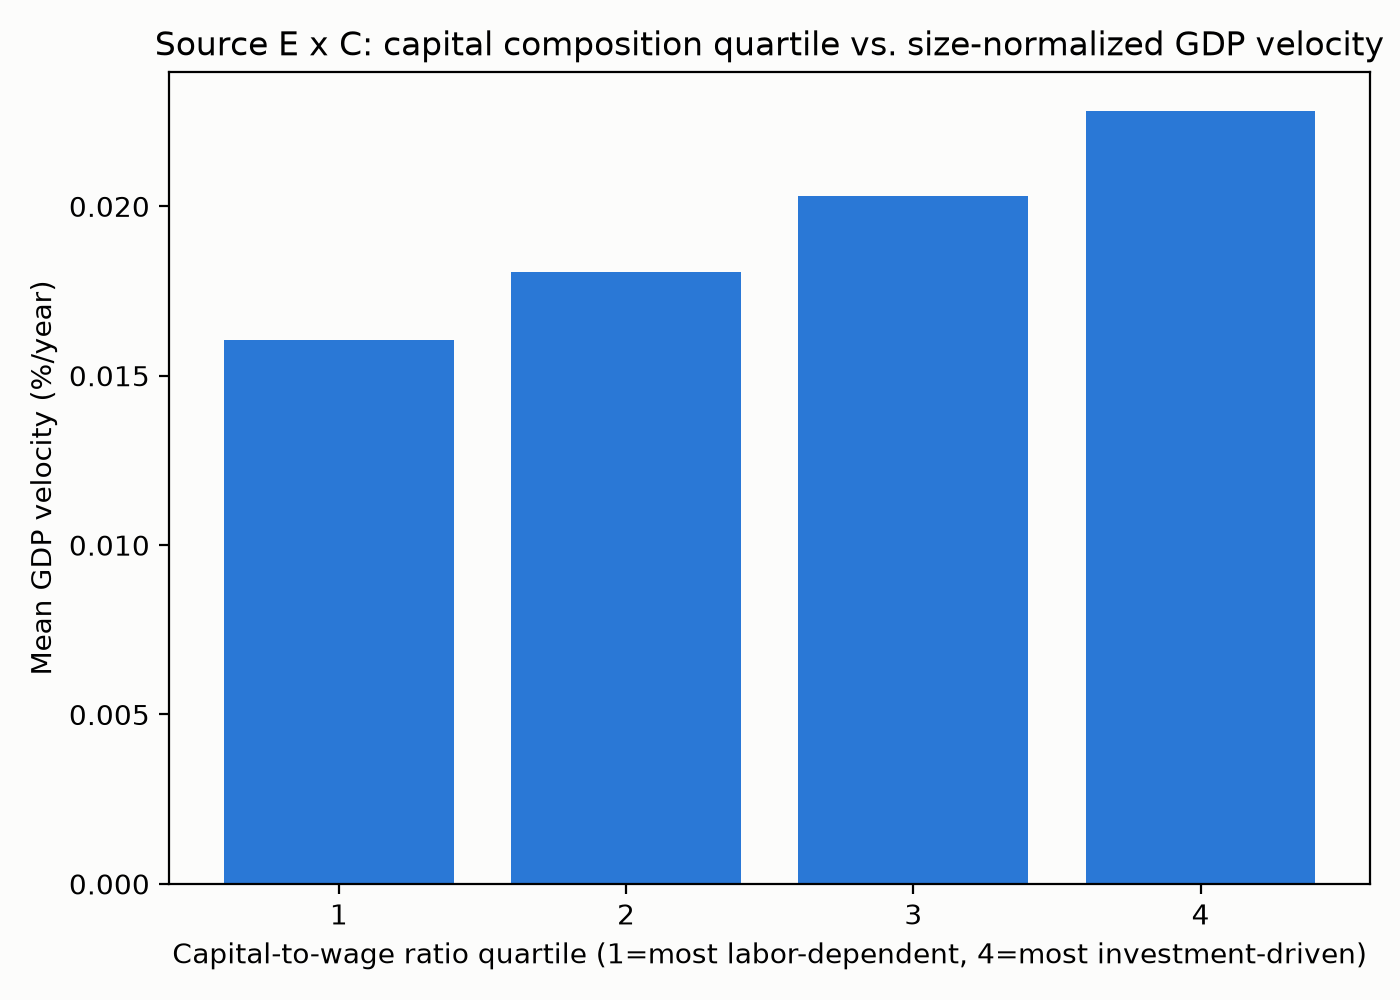

In [15]:
display(Image(filename=str(FIGURES_DIR / "source-e-figure-03-composition-vs-velocity.png")))

## 9. What ships, and proposal alignment

Frozen schema and null semantics: `docs/source_e_feature_schema.md`. Operative
guidance for a consuming model:

- Prefer `capital_to_wage_ratio_normalized_mean` over `capital_to_wage_ratio`.
- Treat the three components as available features, not internals.
- Read `thin_claimer_flag` for "can I trust this level", `low_return_flag` for
  "does this county move my aggregate", `concentrated_gain_flag` for "is this a
  land sale".
- Do **not** weight by `num_returns` to suppress noise. It does the opposite.

Proposal alignment (`source-e-findings.md` §8): the ratio mechanism works as
described and the access mechanism is simpler than the pre-scoping spec assumed.
Round 1 surfaced two limitations neither scoping doc anticipated — no suppression
flag, and tail noise independent of suppression. Round 2 narrowed the second to a
concentrated-gain mechanism and added a third the docs also missed: the ratio's
level is a market-year artifact.

Still open: Kalawao County HI has no row, TY2023 is unpublished, and the source
still ships no suppression flag.